In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Notebook illustrates
- loading psd data saved as numpy npz file 
- mask data of defined frequency band 
- average over frequency band
- save as pandas dataframe
- plot averaged psd over period

@ daniel binder
Golm, 09.06.2026
"""

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set plot parameters
plt.rcParams.update({
    'font.size': 14,        
    'axes.titlesize': 28,   
    'axes.labelsize': 28,   
    'xtick.labelsize': 20,  
    'ytick.labelsize': 20,  
    'legend.fontsize': 20  
})

# Define the file path
base_dir = Path("/media/db/DB_2TBext4/up_env_seismology")
data_dir = base_dir / '02_processed_data/now'

files_to_load = {
    'ZACP': data_dir / 'ZACP_20210802_0809.npz',
    'ZACR': data_dir / 'ZACR_20210802_0809.npz'
}

In [6]:
# Define the frequency band
fmin = 1
fmax = 10

# Master dictionary to temporarily hold data chunks before DataFrame assembly
data_chunks = []

# Loop through each station file and extract the arrays
for station_name, file_path in files_to_load.items():
    if not file_path.exists():
        print(f"File missing: {file_path.name}")
        continue
        
    print(f"Loading and processing: {file_path.name}")
    
    with np.load(file_path, allow_pickle=True) as data:
        psd = data['psd']
        times = data['times']
        frequencies = data['frequencies']
        channels = data['channels']
        
    # Find indices matching the target frequency boundaries
    freq_mask = (frequencies >= fmin) & (frequencies <= fmax)
    band_psd = psd[:, freq_mask]
    
    # Calculate the mean and median columns across the targeted band rows
    mean_values = np.mean(band_psd, axis=1)
    median_values = np.median(band_psd, axis=1)
    
    # Create flat series dictionary rows for this station's contents
    chunk_df = pd.DataFrame({
        'time': pd.to_datetime(times),
        'station': station_name,
        'channel': channels,
        'mean_psd': mean_values,
        'median_psd': median_values
    })
    
    data_chunks.append(chunk_df)

# Concatenate chunks into a single Master DataFrame
df_master = pd.concat(data_chunks, ignore_index=True)

# Set a clean hierarchical MultiIndex (Time, Station, Channel) for easy slicing
df_master = df_master.set_index(['time', 'station', 'channel']).sort_index()

print("\n--- Consolidated Multi-Index Master DataFrame Created ---")
print(df_master.head(15))

# Create filename
csv_fn = (
    f"psds_{fmin}_{fmax}Hz_vs_river_discharge"+
    '_'+
    pd.Timestamp(times.min()).strftime("%Y%m%d")+
    '_'+ 
    pd.Timestamp(times.max()).strftime("%m%d")+
    '.csv'
)
# Save data
df_master.to_csv(data_dir / csv_fn)
print("Averaged PSDs data saved.")

Loading and processing: ZACP_20210802_0809.npz
Loading and processing: ZACR_20210802_0809.npz

--- Consolidated Multi-Index Master DataFrame Created ---
                                         mean_psd    median_psd
time                station channel                            
2021-08-02 00:15:00 ZACP    DPE      2.446333e-22  2.255605e-22
                            DPN      1.107772e-22  9.552814e-23
                            DPZ      9.188320e-23  8.040935e-23
                    ZACR    DPE      7.941755e-22  7.435558e-22
                            DPN      5.575141e-22  5.046727e-22
                            DPZ      1.011242e-21  9.588048e-22
2021-08-02 00:45:00 ZACP    DPE      2.929653e-21  2.522421e-21
                            DPN      2.878688e-21  2.278087e-21
                            DPZ      2.548250e-21  2.232582e-21
                    ZACR    DPE      5.609170e-21  4.941772e-21
                            DPN      6.216703e-21  4.937952e-21
               

                     q_m3_s
2021-08-02 00:15:00  32.424
2021-08-02 00:30:00  33.120
2021-08-02 00:45:00  33.939
2021-08-02 01:00:00  32.136
2021-08-02 01:15:00  32.136
2021-08-02 01:30:00  32.540
2021-08-02 01:45:00  31.334
2021-08-02 02:00:00  31.906
2021-08-02 02:15:00  31.505
2021-08-02 02:30:00  32.251
2021-08-02 02:45:00  30.597
2021-08-02 03:00:00  31.505
2021-08-02 03:15:00  30.766
2021-08-02 03:30:00  29.698
2021-08-02 03:45:00  32.021


<Axes: >

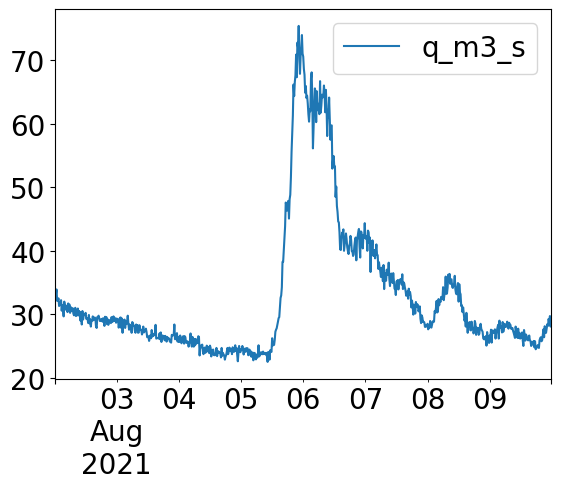

In [7]:
# Load Zackenberg River discharge data
q_dir = base_dir / '01_data/now'
q_fn = "ClimateBasisZackenberg_RiverHydrology_ZackenbergHydrometricSt._Q_15min.dat"

dfq = pd.read_csv(
    q_dir / q_fn,
    sep="\t",
    usecols=["Date", "Time", "discharge"],
    na_values=-9999,
)
dfq.rename(columns={"discharge": "q_m3_s"}, inplace=True)

dfq.index = pd.to_datetime(
    dfq["Date"] + " " + dfq["Time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce",
)
dfq.drop(columns=["Date", "Time"], inplace=True)

# filter period
dfq = dfq.loc[times.min():times.max()]
dfq.dropna(inplace=True)
print(dfq.head(15))

dfq.plot()

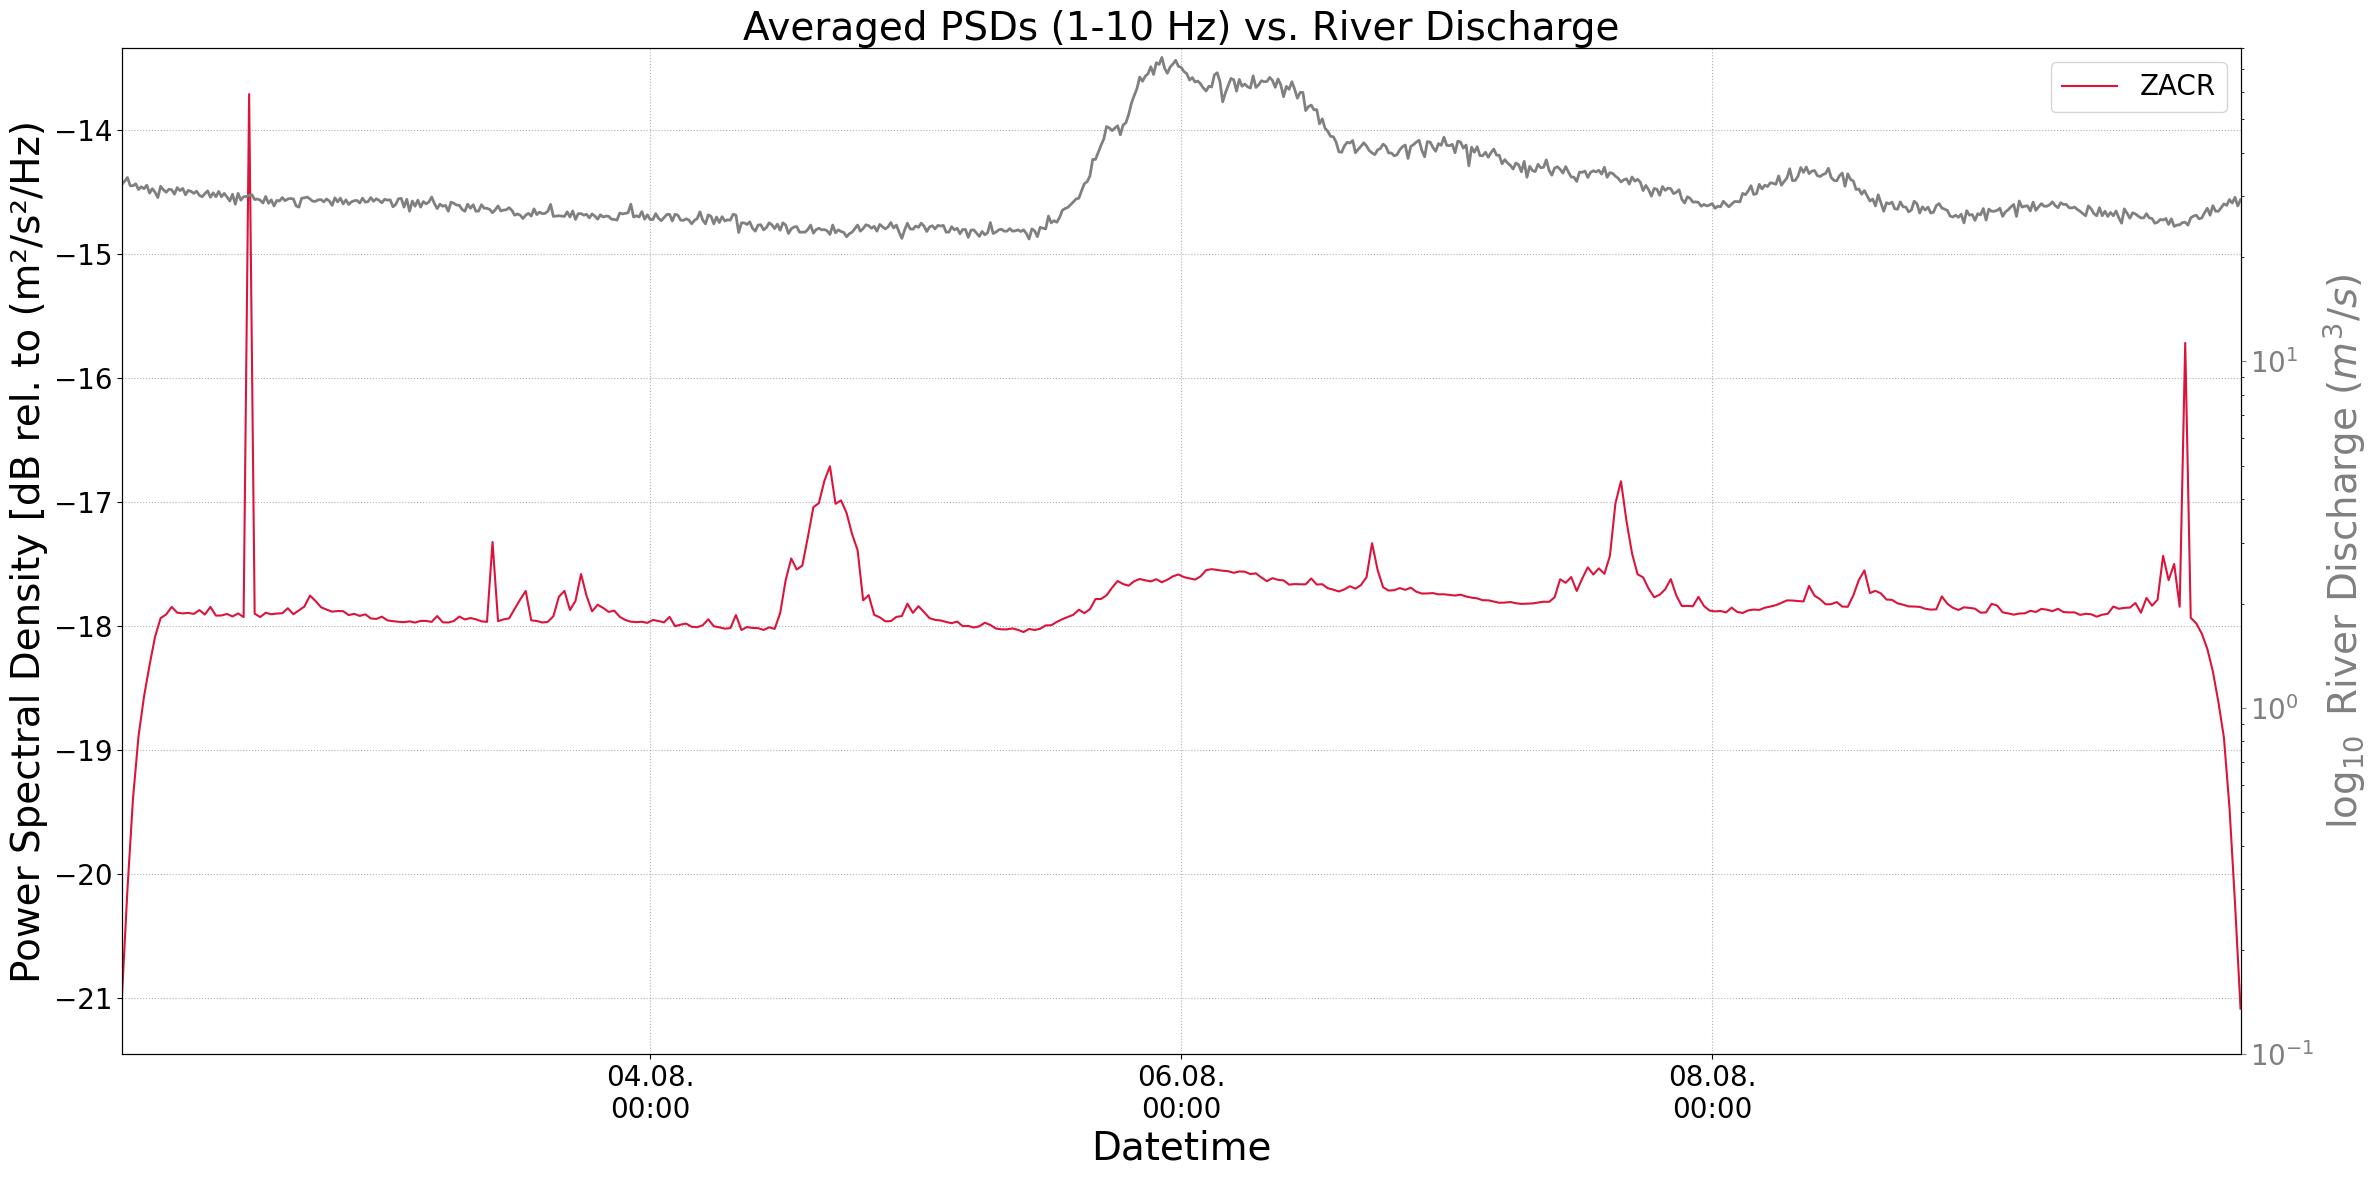

In [10]:
# Slicing the master
df_zacr = df_master.loc[(slice(None), 'ZACR', 'DPZ'), :]
zacr_times = df_zacr.index.get_level_values('time')
df_zacp = df_master.loc[(slice(None), 'ZACP', 'DPZ'), :]
zacp_times = df_zacp.index.get_level_values('time')

# Initialize figure
fig, ax = plt.subplots(figsize=(24, 12))

# Plot PSDs
ax.plot(zacr_times, np.log10(df_zacr['mean_psd']), label='ZACR', color='crimson')
#ax.plot(zacp_times, np.log10(df_zacp['mean_psd']), label='ZACP', color='black')
    
# Format the X-Axis Timestamps
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.\n%H:%M"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))  # Add a date stamp tick every 2 days
ax.grid(True, color='gray', linestyle=':', alpha=0.6)

# Labels and Styling
ax.set_ylabel("Power Spectral Density [dB rel. to (m²/s²/Hz)")
ax.set_xlabel("Datetime")
ax.set_title(f'Averaged PSDs ({fmin}-{fmax} Hz) vs. River Discharge')
ax.legend(loc='upper right')

# Plot river discharge
ax1 = ax.twinx()
ax1.plot(
    dfq.index,
    dfq["q_m3_s"],
    #    label="River discharge",
    color="gray",
    lw=2,
    ls="-",
)
# ax1.set_ylim(-15, 15)
# ax1.set_ylabel("River Discharge (m3/s)")
ax1.set_ylabel(r"$\log_{10}$ River Discharge ($m^3/s$)")
ax1.tick_params(axis="y", colors="gray")
ax1.yaxis.label.set_color("gray")
ax1.set_yscale("log")
ax1.set_ylim(bottom=0.1, top=None)

# find global time limits
global_min = min(zacr_times.min(), pd.Timestamp(dfq.index.min()))
global_max = max(zacr_times.max(), pd.Timestamp(dfq.index.max()))

#global_min = pd.Timestamp('2021-08-04')
#global_min = pd.Timestamp('2021-08-08')

# Synchronize the shared horizontal boundaries explicitly for psd and q
ax.set_xlim(global_min, global_max)
ax1.set_xlim(global_min, global_max)

# Ensure layout fits tightly without clipping labels
plt.tight_layout()

# Save and show plot
figures_dir = base_dir / '03_figures/now'
figures_dir.mkdir(parents=True, exist_ok=True)

# replace extension for png figure
png_fn = csv_fn.replace('.csv', '.png')

plt.savefig(figures_dir / png_fn, dpi=300)

plt.show()